<a href="https://colab.research.google.com/github/divyasri-jonnadula-16/spoken-language-identification/blob/main/ECAPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchaudio scikit-learn matplotlib

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
class LanguageDataset(Dataset):
    def __init__(self, root_dir, sample_rate=16000, duration=3):
        self.root_dir = root_dir
        self.sample_rate = sample_rate
        self.max_length = sample_rate * duration

        self.file_paths = []
        self.labels = []

        self.label_map = {"english":0, "german":1, "spanish":2}

        for lang in os.listdir(root_dir):
            lang_path = os.path.join(root_dir, lang)
            if os.path.isdir(lang_path):
                for file in os.listdir(lang_path):
                    if file.endswith(".flac"):
                        self.file_paths.append(os.path.join(lang_path, file))
                        self.labels.append(self.label_map[lang])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)

        if sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
            waveform = resampler(waveform)

        if waveform.size(1) > self.max_length:
            waveform = waveform[:, :self.max_length]
        else:
            pad = self.max_length - waveform.size(1)
            waveform = F.pad(waveform, (0, pad))

        return waveform.squeeze(0), torch.tensor(label)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

train_dataset = LanguageDataset("/content/drive/MyDrive/spokenvoice/train")
test_dataset = LanguageDataset("/content/drive/MyDrive/spokenvoice/test")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000,
            n_mels=80
        )
        self.db = torchaudio.transforms.AmplitudeToDB()

    def forward(self, x):
        x = self.mel(x)
        x = self.db(x)
        return x

In [ ]:
class ECAPA_TDNN(nn.Module):
    def __init__(self, input_dim=80, channels=512, num_classes=3):
        super().__init__()

        self.layer1 = nn.Conv1d(input_dim, channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(channels)

        self.layer2 = nn.Conv1d(channels, channels, kernel_size=3, padding=2, dilation=2)
        self.bn2 = nn.BatchNorm1d(channels)

        self.layer3 = nn.Conv1d(channels, channels, kernel_size=3, padding=3, dilation=3)
        self.bn3 = nn.BatchNorm1d(channels)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(channels, 192)
        self.classifier = nn.Linear(192, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.layer1(x)))
        x = F.relu(self.bn2(self.layer2(x)))
        x = F.relu(self.bn3(self.layer3(x)))

        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc(x))
        x = self.classifier(x)

        return x

In [ ]:
feature_extractor = FeatureExtractor().to(device)
model = ECAPA_TDNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for audio, labels in train_loader:
        audio, labels = audio.to(device), labels.to(device)

        features = feature_extractor(audio)
        outputs = model(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/20, Loss: 0.3717
Epoch 2/20, Loss: 0.1537
Epoch 3/20, Loss: 0.1016
Epoch 4/20, Loss: 0.0698
Epoch 5/20, Loss: 0.0765
Epoch 6/20, Loss: 0.0594
Epoch 7/20, Loss: 0.0441
Epoch 8/20, Loss: 0.0392
Epoch 9/20, Loss: 0.0452
Epoch 10/20, Loss: 0.0399
Epoch 11/20, Loss: 0.0186
Epoch 12/20, Loss: 0.0297
Epoch 13/20, Loss: 0.0404
Epoch 14/20, Loss: 0.0302
Epoch 15/20, Loss: 0.0257
Epoch 16/20, Loss: 0.0302
Epoch 17/20, Loss: 0.0168
Epoch 18/20, Loss: 0.0285
Epoch 19/20, Loss: 0.0122
Epoch 20/20, Loss: 0.0363


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for audio, labels in test_loader:
        audio = audio.to(device)
        labels = labels.to(device)

        features = feature_extractor(audio)
        outputs = model(features)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
print("Classification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["English", "German", "Spanish"]
))

Classification Report:

              precision    recall  f1-score   support

     English       0.63      0.59      0.61       180
      German       0.74      0.32      0.44       180
     Spanish       0.58      0.96      0.72       180

    accuracy                           0.62       540
   macro avg       0.65      0.62      0.59       540
weighted avg       0.65      0.62      0.59       540



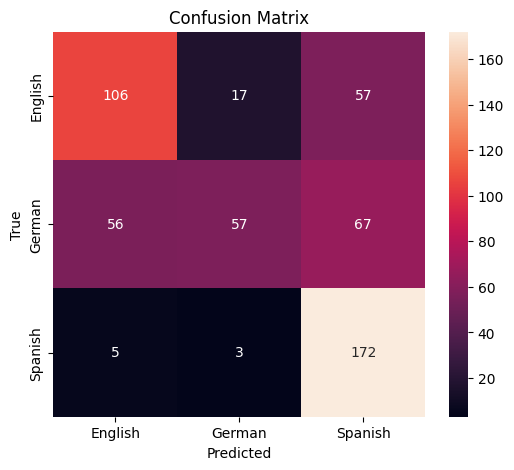

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["English","German","Spanish"],
            yticklabels=["English","German","Spanish"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(len(train_dataset))
print(len(test_dataset))

6000
540
